In [83]:
!pip install gender-guesser

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gender_guesser.detector as gender

# Configuración visual de alta gama
sns.set_theme(style="whitegrid", context="talk")

print("Iniciando extracción masiva de datos (ETL) de 100K registros...")

# Cargar archivos masivos
df_pacientes = pd.read_csv('data_pacientes.txt', sep='|', names=['Cedula', 'Nombre_Paciente', 'Edad_Paciente', 'Telefono', 'Clave'], dtype=str)
df_pacientes['Edad_Paciente'] = pd.to_numeric(df_pacientes['Edad_Paciente'], errors='coerce')

df_medicos = pd.read_csv('data_medicos.txt', sep='|', names=['Codigo_Medico', 'Nombre_Medico', 'Edad_Medico', 'Especialidad', 'Horario', 'Clave'], dtype=str)

df_citas = pd.read_csv('data_citas.txt', sep='|', names=['ID_Cita', 'Cedula', 'Codigo_Medico', 'Fecha', 'Hora', 'Motivo', 'Estado'], dtype=str)
df_citas['Estado'] = pd.to_numeric(df_citas['Estado'])

print(f" ETL Completado: {len(df_pacientes)} Pacientes, {len(df_medicos)} Médicos, {len(df_citas)} Citas extraídas.")

Iniciando extracción masiva de datos (ETL) de 100K registros...
 ETL Completado: 15000 Pacientes, 500 Médicos, 30000 Citas extraídas.


In [85]:
# 1. Merge: Construcción del Data Warehouse
df_mis = pd.merge(df_citas, df_pacientes[['Cedula', 'Nombre_Paciente', 'Edad_Paciente']], on='Cedula', how='left')
df_mis = pd.merge(df_mis, df_medicos[['Codigo_Medico', 'Nombre_Medico', 'Especialidad', 'Horario']], on='Codigo_Medico', how='left')

# 2. Mapeo de Estados y Multas
mapa_estados = {0: 'Activa', 1: 'Cancelada', 2: 'Atendida', 3: 'No Asistió'}
df_mis['Estado_Texto'] = df_mis['Estado'].map(mapa_estados)
df_mis['Multa_Recaudada'] = df_mis['Estado'].apply(lambda x: 25.00 if x == 3 else 0.0)

# Formateo de fechas
df_mis['Fecha_DT'] = pd.to_datetime(df_mis['Fecha'], format='%d-%m-%Y', errors='coerce')
df_mis['Mes_Anio'] = df_mis['Fecha_DT'].dt.to_period('M')

# Segmentación Demográfica (Edad)
df_mis['Segmento_Cliente'] = df_mis['Edad_Paciente'].apply(lambda e: 'Adolescentes (13-17)' if e < 18 else ('Adultos (18-64)' if e <= 64 else 'Geriátricos (65+)'))
df_mis['Turno_Asignado'] = df_mis['Horario'].apply(lambda x: 'Turno Mañana' if '08:00' in str(x) else 'Turno Tarde')


# 3. MÓDULO DE ENRIQUECIMIENTO: IDENTIFICACIÓN DE GÉNERO

print("Analizando demografía de género...")
detector = gender.Detector(case_sensitive=False)

# Extraemos solo el primer nombre
df_mis['Primer_Nombre'] = df_mis['Nombre_Paciente'].apply(lambda x: str(x).split()[0])

def adivinar_genero(nombre):
    gen = detector.get_gender(nombre)
    if gen in ['male', 'mostly_male']: return 'Masculino'
    elif gen in ['female', 'mostly_female']: return 'Femenino'
    else: return 'No Definido'

#  Solo analizamos los nombres únicos en lugar de 100,000 filas
nombres_unicos = df_mis['Primer_Nombre'].unique()
mapa_generos = {nombre: adivinar_genero(nombre) for nombre in nombres_unicos}

# Mapeamos el resultado a nuestra base de datos gigante instantáneamente
df_mis['Genero'] = df_mis['Primer_Nombre'].map(mapa_generos)


print(f" Datos transformados. Recaudación total recuperada: ${df_mis['Multa_Recaudada'].sum():,.2f} USD")

Analizando demografía de género...
 Datos transformados. Recaudación total recuperada: $26,825.00 USD


/tmp/ipykernel_3117/1928197671.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_especialidades.values, y=top_especialidades.index, ax=axes[1, 0], palette='Blues_r')
/tmp/ipykernel_3117/1928197671.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_motivos.values, y=top_motivos.index, ax=axes[1, 1], palette='crest')
/tmp/ipykernel_3117/1928197671.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pacientes_multas.values, y=top_pacientes_multas.index, ax=axes[2, 0], palette='Reds_r')
/tmp/ipykernel_3117/1928197671.py:5

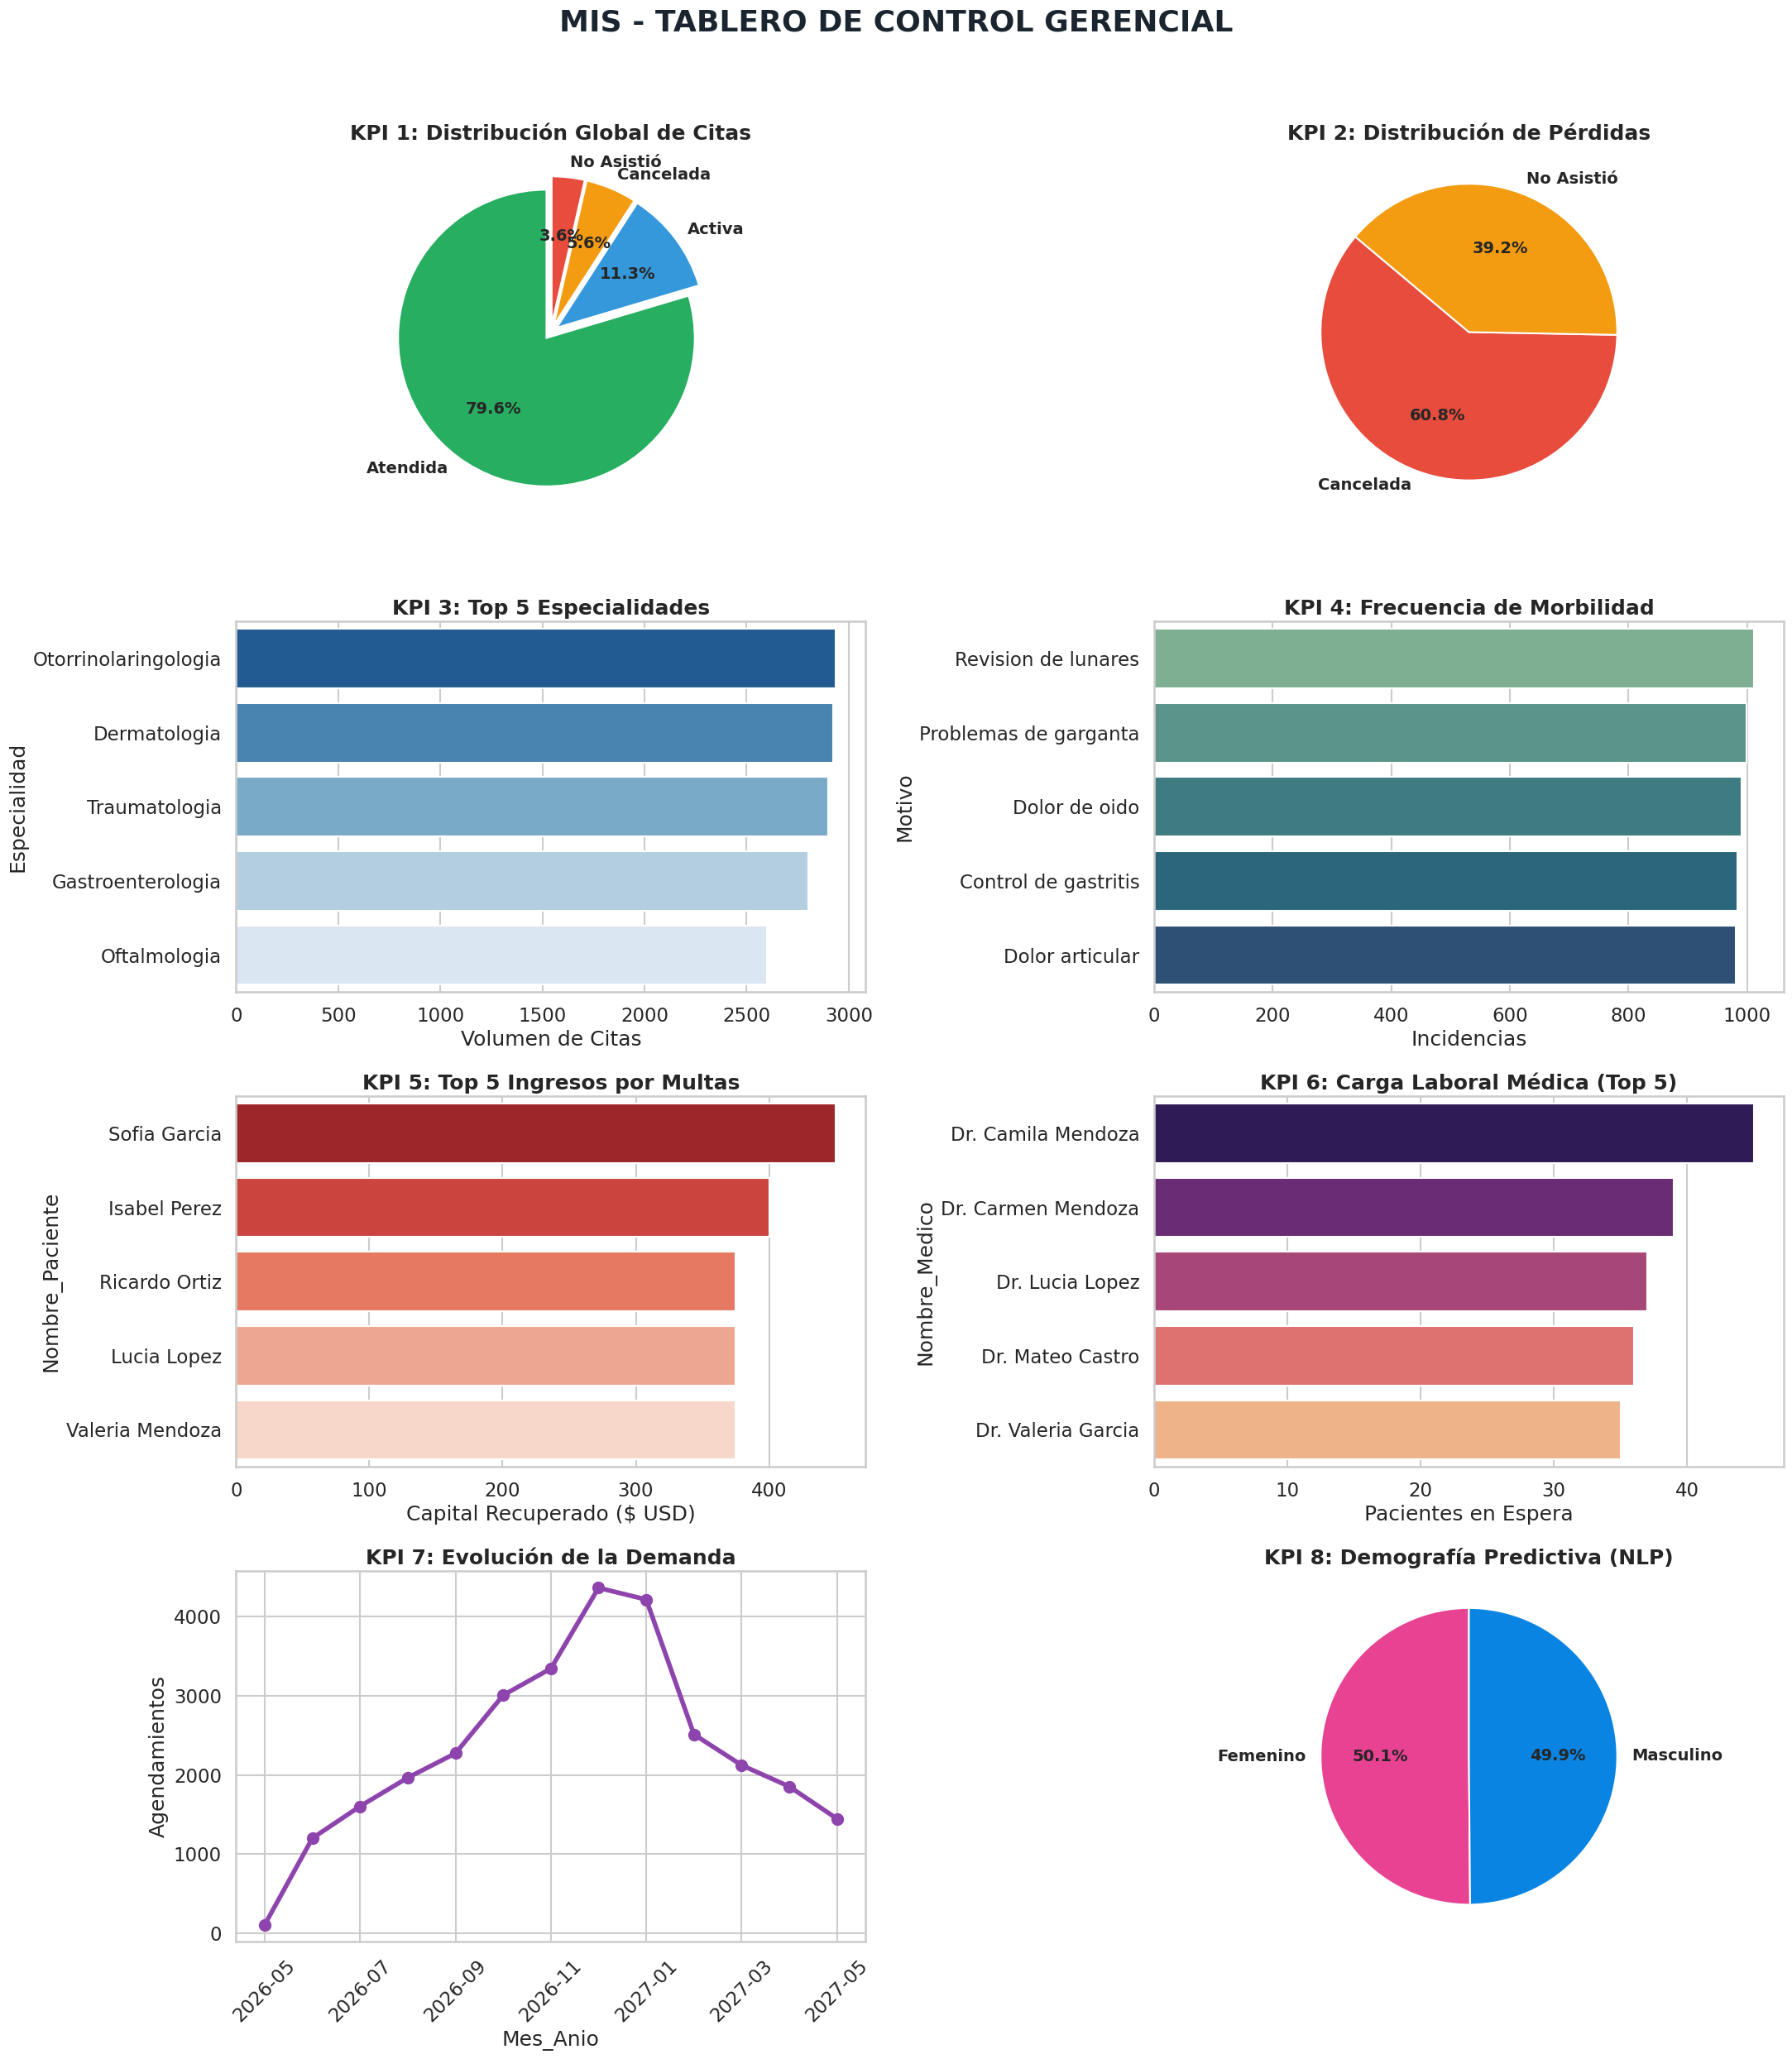

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual
sns.set_theme(style="whitegrid", context="talk")

# Creación del lienzo: 4 filas x 2 columnas = 8 KPIs exactos
fig, axes = plt.subplots(4, 2, figsize=(22, 26))
fig.suptitle('MIS - TABLERO DE CONTROL GERENCIAL', fontsize=26, fontweight='bold', color='#1a252f', y=0.98)


# KPI 1: Distribución Global de Citas (Los 4 estados)
dist_estados = df_mis['Estado_Texto'].value_counts()
colores_est = {'Atendida': '#27ae60', 'Activa': '#3498db', 'No Asistió': '#e74c3c', 'Cancelada': '#f39c12'}

axes[0, 0].pie(dist_estados, labels=dist_estados.index, autopct='%1.1f%%',
               colors=[colores_est.get(x, '#333') for x in dist_estados.index],
               startangle=90, textprops={'fontsize': 14, 'weight': 'bold'},
               explode=[0.05]*len(dist_estados)) # Pequeña separación para verse más premium
axes[0, 0].set_title('KPI 1: Distribución Global de Citas', fontweight='bold', fontsize=18)

# KPI 2: Distribución de Fuga de Capital (Zoom a las pérdidas)
fuga_df = df_mis[df_mis['Estado'].isin([1, 3])]['Estado_Texto'].value_counts()
axes[0, 1].pie(fuga_df, labels=fuga_df.index, autopct='%1.1f%%', colors=['#e74c3c', '#f39c12'], startangle=140, textprops={'fontsize': 14, 'weight': 'bold'})
axes[0, 1].set_title('KPI 2: Distribución de Pérdidas', fontweight='bold', fontsize=18)


# KPI 3: Top 5 Servicios Estrella (Rúbrica: Top 5 Productos por volumen)
top_especialidades = df_mis['Especialidad'].value_counts().head(5)
sns.barplot(x=top_especialidades.values, y=top_especialidades.index, ax=axes[1, 0], palette='Blues_r')
axes[1, 0].set_title('KPI 3: Top 5 Especialidades', fontweight='bold', fontsize=18)
axes[1, 0].set_xlabel('Volumen de Citas')

# KPI 4: Top 5 Motivos de Consulta
top_motivos = df_mis['Motivo'].value_counts().head(5)
sns.barplot(x=top_motivos.values, y=top_motivos.index, ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('KPI 4: Frecuencia de Morbilidad', fontweight='bold', fontsize=18)
axes[1, 1].set_xlabel('Incidencias')



# KPI 5: Top 5 Pacientes Infractores (Rúbrica: Top 5 Clientes por ingresos)
top_pacientes_multas = df_mis[df_mis['Estado'] == 3].groupby('Nombre_Paciente')['Multa_Recaudada'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_pacientes_multas.values, y=top_pacientes_multas.index, ax=axes[2, 0], palette='Reds_r')
axes[2, 0].set_title('KPI 5: Top 5 Ingresos por Multas', fontweight='bold', fontsize=18)
axes[2, 0].set_xlabel('Capital Recuperado ($ USD)')

# KPI 6: Riesgo de Burnout Médico
citas_activas = df_mis[df_mis['Estado'] == 0]
top_medicos = citas_activas['Nombre_Medico'].value_counts().head(5)
sns.barplot(x=top_medicos.values, y=top_medicos.index, ax=axes[2, 1], palette='magma')
axes[2, 1].set_title('KPI 6: Carga Laboral Médica (Top 5)', fontweight='bold', fontsize=18)
axes[2, 1].set_xlabel('Pacientes en Espera')



# KPI 7: Evolución Temporal
tendencia = df_mis.groupby('Mes_Anio').size().sort_index()
tendencia.index = tendencia.index.astype(str)
tendencia.plot(kind='line', marker='o', ax=axes[3, 0], color='#8e44ad', linewidth=4, markersize=10)
axes[3, 0].set_title('KPI 7: Evolución de la Demanda', fontweight='bold', fontsize=18)
axes[3, 0].set_ylabel('Agendamientos')
axes[3, 0].tick_params(axis='x', rotation=45)

# KPI 8: Distribución de Género
gen_counts = df_mis['Genero'].value_counts()
colores_gen = {'Femenino': '#e84393', 'Masculino': '#0984e3', 'No Definido': '#b2bec3'}
axes[3, 1].pie(gen_counts, labels=gen_counts.index, autopct='%1.1f%%', colors=[colores_gen.get(x, '#333') for x in gen_counts.index], startangle=90, textprops={'fontsize': 14, 'weight':'bold'})
axes[3, 1].set_title('KPI 8: Demografía Predictiva (NLP)', fontweight='bold', fontsize=18)

# Ajuste visual
plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()